In [ ]:
# Cart Abandonment Prediction Project
# Dataset: Ecommerce behavior data from multi category store

!pip install kaggle -q

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rishabh005","key":"80136a8d813614c4f18be55a5c202c2a"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d mkechinov/ecommerce-behavior-data-from-multi-category-store
!unzip ecommerce-behavior-data-from-multi-category-store.zip -d ecommerce_data

Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store
License(s): copyright-authors
100% 4.29G/4.29G [02:52<00:00, 26.7MB/s]

Archive:  ecommerce-behavior-data-from-multi-category-store.zip
  inflating: ecommerce_data/2019-Nov.csv  
  inflating: ecommerce_data/2019-Oct.csv  


In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

In [ ]:
csv_files = glob.glob("/content/ecommerce_data/*.csv")
csv_files

['/content/ecommerce_data/2019-Nov.csv',
 '/content/ecommerce_data/2019-Oct.csv']

In [ ]:
data_path = csv_files[0]

df = pd.read_csv(data_path, nrows=1000000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1000000 non-null  object 
 1   event_type     1000000 non-null  object 
 2   product_id     1000000 non-null  int64  
 3   category_id    1000000 non-null  int64  
 4   category_code  683023 non-null   object 
 5   brand          852803 non-null   object 
 6   price          1000000 non-null  float64
 7   user_id        1000000 non-null  int64  
 8   user_session   1000000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 68.7+ MB


In [ ]:
df = df[['event_time', 'event_type', 'product_id', 'category_id',
         'category_code', 'brand', 'price', 'user_id', 'user_session']]

In [ ]:
df['event_time'] = pd.to_datetime(df['event_time'])

df['brand'] = df['brand'].fillna("unknown")
df['category_code'] = df['category_code'].fillna("unknown")
df['user_session'] = df['user_session'].fillna("unknown")

df = df.dropna(subset=['price'])
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00+00:00,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00+00:00,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01+00:00,view,17302664,2053013553853497655,unknown,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01+00:00,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01+00:00,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [ ]:
df['event_type'].value_counts()

,count
event_type,
view,967225
purchase,17817
cart,14958


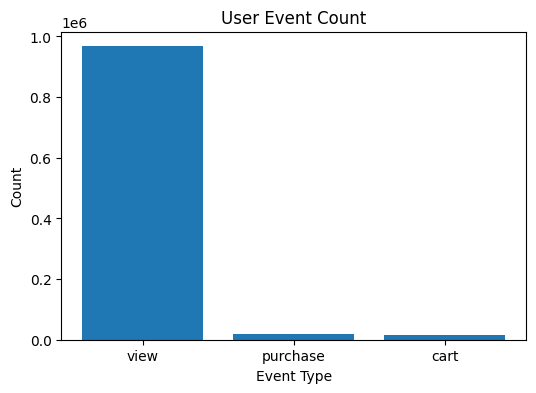

In [ ]:
event_counts = df['event_type'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(event_counts.index, event_counts.values)
plt.title("User Event Count")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

In [ ]:
cart_data = df[df['event_type'] == 'cart'].copy()
purchase_data = df[df['event_type'] == 'purchase'].copy()

print("Cart records:", cart_data.shape)
print("Purchase records:", purchase_data.shape)

Cart records: (14958, 9)
Purchase records: (17817, 9)


In [ ]:
purchased_items = purchase_data[['user_session', 'product_id']].drop_duplicates()
purchased_items['purchased'] = 1

cart_data = cart_data.merge(
    purchased_items,
    on=['user_session', 'product_id'],
    how='left'
)

cart_data['purchased'] = cart_data['purchased'].fillna(0).astype(int)
cart_data['abandoned'] = 1 - cart_data['purchased']

cart_data[['user_session', 'product_id', 'purchased', 'abandoned']].head()

,user_session,product_id,purchased,abandoned
0,6b928be2-2bce-4640-8296-0efdf2fda22a,1005014,0,1
1,4d76d6d3-fff5-4880-8327-e9e57b618e0e,1801881,1,0
2,fd4bd6d4-bd14-4fdc-9aff-bd41a594f82e,1005115,0,1
3,dcbdc6e4-cd49-4ee8-95c5-e85f3c618fa1,1002542,0,1
4,61ceaf50-820a-4858-9a68-bab804d47a22,1004856,1,0


In [ ]:
cart_data['abandoned'].value_counts()

,count
abandoned,
0,8244
1,6714


In [ ]:
session_data = df.groupby('user_session').agg(
    total_events=('event_type', 'count'),
    view_count=('event_type', lambda x: (x == 'view').sum()),
    cart_count=('event_type', lambda x: (x == 'cart').sum()),
    purchase_count=('event_type', lambda x: (x == 'purchase').sum()),
    unique_products=('product_id', 'nunique'),
    avg_price=('price', 'mean'),
    max_price=('price', 'max'),
    min_price=('price', 'min')
).reset_index()

session_data.head()

,user_session,total_events,view_count,cart_count,purchase_count,unique_products,avg_price,max_price,min_price
0,00006bc8-78c7-4100-ba97-37352c9af491,13,13,0,0,6,72.362308,78.51,69.50
1,00008ebc-a8c1-48c2-beb9-aa4448e93639,4,4,0,0,2,150.980000,151.07,150.89
2,0000b0f0-9fb0-41a3-bdfa-3fa1d28b2e7c,4,4,0,0,1,218.770000,218.77,218.77
3,0000cf90-3ea4-4526-aca3-a48a739b66f1,2,2,0,0,2,125.020000,128.18,121.86
4,0000d82e-3614-4362-a1d3-2a56a895fdc6,2,2,0,0,2,102.125000,139.14,65.11


In [ ]:
final_data = cart_data.merge(session_data, on='user_session', how='left')
final_data.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,purchased,abandoned,total_events,view_count,cart_count,purchase_count,unique_products,avg_price,max_price,min_price
0,2019-11-01 00:00:14+00:00,cart,1005014,2053013555631882655,electronics.smartphone,samsung,503.09,533326659,6b928be2-2bce-4640-8296-0efdf2fda22a,0,1,1,0,1,0,1,503.090000,503.09,503.09
1,2019-11-01 00:03:24+00:00,cart,1801881,2053013554415534427,electronics.video.tv,samsung,488.80,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e,1,0,25,11,7,7,1,488.800000,488.80,488.80
2,2019-11-01 00:03:39+00:00,cart,1005115,2053013555631882655,electronics.smartphone,apple,949.47,565865924,fd4bd6d4-bd14-4fdc-9aff-bd41a594f82e,0,1,2,1,1,0,1,949.470000,949.47,949.47
3,2019-11-01 00:05:54+00:00,cart,1002542,2053013555631882655,electronics.smartphone,apple,486.80,549256216,dcbdc6e4-cd49-4ee8-95c5-e85f3c618fa1,0,1,14,11,2,1,5,519.409286,617.52,458.28
4,2019-11-01 00:06:38+00:00,cart,1004856,2053013555631882655,electronics.smartphone,samsung,128.42,513645631,61ceaf50-820a-4858-9a68-bab804d47a22,1,0,9,4,4,1,1,128.420000,128.42,128.42


In [ ]:
from sklearn.preprocessing import LabelEncoder

brand_encoder = LabelEncoder()
category_encoder = LabelEncoder()

final_data['brand'] = brand_encoder.fit_transform(final_data['brand'].astype(str))
final_data['category_code'] = category_encoder.fit_transform(final_data['category_code'].astype(str))

In [ ]:
features = [
    'price',
    'brand',
    'category_code',
    'total_events',
    'view_count',
    'cart_count',
    'unique_products',
    'avg_price',
    'max_price',
    'min_price'
]

X = final_data[features]
y = final_data['abandoned']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(11966, 10)
(2992, 10)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8556149732620321
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1649
           1       0.85      0.83      0.84      1343

    accuracy                           0.86      2992
   macro avg       0.85      0.85      0.85      2992
weighted avg       0.86      0.86      0.86      2992

[[1448  201]
 [ 231 1112]]


In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
3,total_events,0.318653
4,view_count,0.173388
5,cart_count,0.130757
7,avg_price,0.073298
0,price,0.065796
9,min_price,0.060477
8,max_price,0.060065
6,unique_products,0.049512
1,brand,0.035998
2,category_code,0.032056


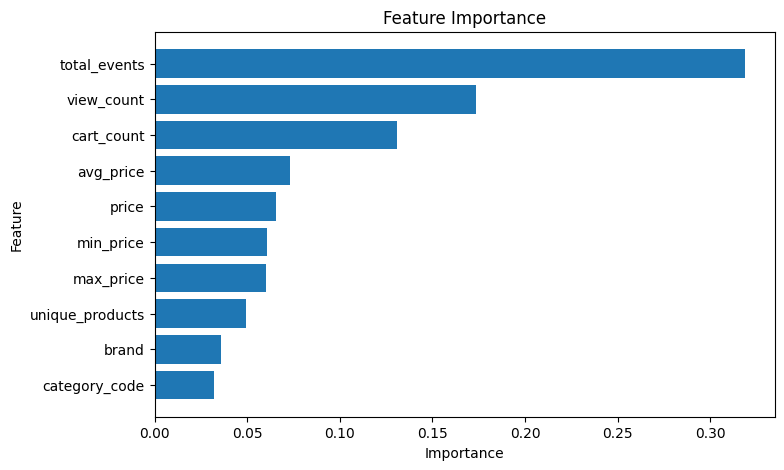

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
sample = X_test.iloc[[0]]

result = model.predict(sample)[0]
prob = model.predict_proba(sample)[0][1]

print("Abandonment Probability:", round(prob * 100, 2), "%")

if prob < 0.4:
    print("Risk Level: Low")
elif prob < 0.7:
    print("Risk Level: Medium")
else:
    print("Risk Level: High")

if result == 1:
    print("Final Prediction: User may abandon the cart")
else:
    print("Final Prediction: User may purchase the product")

Abandonment Probability: 47.82 %
Risk Level: Medium
Final Prediction: User may purchase the product


In [ ]:
import joblib

joblib.dump(model, "cart_abandonment_model.pkl")
joblib.dump(brand_encoder, "brand_encoder.pkl")
joblib.dump(category_encoder, "category_encoder.pkl")

print("Files saved")

Files saved


In [ ]:
from google.colab import files

files.download("cart_abandonment_model.pkl")
files.download("brand_encoder.pkl")
files.download("category_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>